<a href="https://colab.research.google.com/github/kc-ck/BUS888-Codebase/blob/main/10B_ComparingStrategies_w_Backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt

In [3]:
# Constants
TICKER = "NVDA"
START_DATE = '2021-07-01'
END_DATE = '2026-07-30'
LOOK_BACK = 30
EPOCHS = 50
BATCH_SIZE = 10

INITIAL_BALANCE = 10000  # Initial balance in dollars
TRANSACTION_COST = 0  # Cost per transaction in dollars
MAX_BUY_LIMIT = 100  # Maximum number of stocks to buy per transaction

## Functions: Data Prep

In [4]:
# Functions for data fetching and preparation
def fetch_stock_data(ticker=TICKER, start_date=START_DATE, end_date=END_DATE):
    return yf.download(ticker, start=start_date, end=end_date)

def prepare_data_without_scaling(data, look_back):
    close_prices = data['Close'].values.reshape(-1, 1)
    X, y = [], []
    for i in range(look_back, len(close_prices)):
        X.append(close_prices[i - look_back:i, 0])
        y.append(close_prices[i, 0])
    return np.array(X), np.array(y)

def split_data(X, y, ratio=0.8):
    train_size = int(len(X) * ratio)
    return X[:train_size], X[train_size:], y[:train_size], y[train_size:]

def build_model(input_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

def rolling_prediction(model, X_test, look_back, steps_ahead=1):
    test_predictions = []
    for i in range(0, len(X_test) - steps_ahead + 1):
        current_batch = X_test[i].reshape(1, look_back)
        for j in range(steps_ahead):
            current_pred = model.predict(current_batch)[0]
            test_predictions.append(current_pred)
            current_batch = np.roll(current_batch, -1)
            if j < steps_ahead - 1:
                current_batch[-1][-1] = current_pred
    return test_predictions


## Trading Strategies Based on Neural Network Price Predictions

## Strategy 1: Simple Prediction-Based Trading
This strategy uses the predicted price for the next day to make trading decisions.

### Buy Signal
- Buy if the predicted price for the next day is higher than the current day's price, and there are enough funds to purchase at least one stock.

### Sell Signal
- Sell if the predicted price for the next day is lower than the current day's price, and there are stocks available to sell.

### Summary
This strategy relies purely on the neural network's prediction of the next day's price to make buy and sell decisions, aiming to capitalize on short-term price movements.

In [5]:
def trading_strategy1(y_test_original, test_predictions_original):
    balance = INITIAL_BALANCE
    stock_count = 0
    account_values = [INITIAL_BALANCE]
    buy_points, sell_points = [],[]
    for i in range(len(y_test_original) - 1):
        today_price = y_test_original[i][0]
        predicted_next_day_price = test_predictions_original[i + 1][0]
        account_value = balance + stock_count * today_price
        account_values.append(account_value)
        if predicted_next_day_price > today_price and balance > today_price and stock_count == 0:
            stock_count += 1
            balance -= today_price
            buy_points.append((i, today_price))
        elif predicted_next_day_price < today_price and stock_count > 0:
            stock_count -= 1
            balance += today_price
            sell_points.append((i, today_price))
    if stock_count >= 1:
        balance += stock_count * y_test_original[-1][0]
        stock_count = 0
    account_values.append(balance)
    return balance, buy_points, sell_points, account_values


## Strategy 2: Prediction with Transaction Limits
This strategy also uses the predicted price for the next day but includes transaction limits to manage risk.

### Buy Signal
- Buy a limited number of stocks (maximum set by `MAX_BUY_LIMIT`) if the predicted price for the next day is higher than the current day's price.

### Sell Signal
- Sell all holdings if the predicted price for the next day is lower than the current day's price.

### Summary
This strategy adds a constraint on the number of stocks bought in each transaction to limit exposure and manage risk, making it more conservative than Strategy 1.

In [6]:
def trading_strategy2(y_test_original, test_predictions_original):
    balance = INITIAL_BALANCE
    transaction_cost = TRANSACTION_COST
    max_buy_limit = MAX_BUY_LIMIT
    stock_count = 0
    buy_points, sell_points, account_values = [], [], []
    for i in range(len(y_test_original) - 1):
        today_price = y_test_original[i][0]
        predicted_next_day_price = test_predictions_original[i + 1][0]
        account_value = balance + stock_count * today_price
        account_values.append(account_value)
        max_stocks_to_buy = min(max_buy_limit, balance // (today_price + transaction_cost))
        if predicted_next_day_price > today_price and max_stocks_to_buy > 0:
            stock_count += max_stocks_to_buy
            balance -= (today_price + transaction_cost) * max_stocks_to_buy
            buy_points.append((i, today_price, max_stocks_to_buy))
        elif predicted_next_day_price < today_price and stock_count > 0:
            balance += (today_price - transaction_cost) * stock_count
            sell_points.append((i, today_price, stock_count))
            stock_count = 0
    if stock_count > 0:
        balance += y_test_original[-1][0] * stock_count
        stock_count = 0
    account_values.append(balance)
    return balance, buy_points, sell_points, account_values

## Strategy 3: Moving Average Crossover with Predictions
This strategy combines the moving average crossover technique with neural network price predictions.

### Buy Signal
- Buy if the predicted price for the next day crosses above the long-term moving average of the actual closing prices, and there are no stocks currently held.

### Sell Signal
- Sell if the predicted price for the next day crosses below the short-term moving average of the actual closing prices, and stocks are currently held.

### Summary
This strategy uses the neural network's predictions in conjunction with traditional moving average signals to refine entry and exit points, aiming to capture trends.

In [7]:
def moving_average_crossover_strategy(y_test_original, test_predictions_original, short_window=20, long_window=50):
    balance = INITIAL_BALANCE
    stock_count = 0
    account_values = [INITIAL_BALANCE]
    buy_points, sell_points = [], []
    for i in range(long_window, len(y_test_original) - 1):
        today_price = y_test_original[i][0]
        predicted_next_day_price = test_predictions_original[i + 1][0]

        short_ma = np.mean(y_test_original[i - short_window:i])
        long_ma = np.mean(y_test_original[i - long_window:i])

        account_value = balance + stock_count * today_price
        account_values.append(account_value)

        if predicted_next_day_price > long_ma and stock_count == 0:
            stock_count += 1
            balance -= today_price
            buy_points.append((i, today_price))
        elif predicted_next_day_price < short_ma and stock_count > 0:
            stock_count -= 1
            balance += today_price
            sell_points.append((i, today_price))

    if stock_count >= 1:
        balance += stock_count * y_test_original[-1][0]
        stock_count = 0
    account_values.append(balance)

    return balance, buy_points, sell_points, account_values

## Strategy 4: Prediction-Based Mean Reversion
This strategy is based on the mean reversion principle, using predicted prices to identify overbought and oversold conditions.

### Buy Signal
- Buy if the predicted price for the next day is significantly below the historical mean price.

### Sell Signal
- Sell if the predicted price for the next day is significantly above the historical mean price.

### Summary
This strategy assumes that prices tend to revert to their historical average over time. It uses the neural network's predictions to identify when prices are likely to revert, aiming to profit from these corrections.

In [8]:
def mean_reversion_strategy(y_test_original, test_predictions_original, threshold=0.05):
    balance = INITIAL_BALANCE
    stock_count = 0
    account_values = [INITIAL_BALANCE]
    buy_points, sell_points = [], []
    mean_price = np.mean(y_test_original)

    for i in range(len(y_test_original) - 1):
        today_price = y_test_original[i][0]
        predicted_next_day_price = test_predictions_original[i + 1][0]

        account_value = balance + stock_count * today_price
        account_values.append(account_value)

        if predicted_next_day_price < mean_price * (1 - threshold) and stock_count == 0:
            stock_count += 1
            balance -= today_price
            buy_points.append((i, today_price))
        elif predicted_next_day_price > mean_price * (1 + threshold) and stock_count > 0:
            stock_count -= 1
            balance += today_price
            sell_points.append((i, today_price))

    if stock_count >= 1:
        balance += stock_count * y_test_original[-1][0]
        stock_count = 0
    account_values.append(balance)

    return balance, buy_points, sell_points, account_values

## Functions: BAcktesting

In [9]:
def calculate_performance(account_values, risk_free_rate=0.03):
    account_values = np.array(account_values).flatten() # Ensure account_values is a 1D array
    total_return = (account_values[-1] - account_values[0]) / account_values[0] * 100
    num_years = (len(account_values) / 252)
    annualized_return = (account_values[-1] / account_values[0])**(1 / num_years) - 1
    cagr = (account_values[-1] / account_values[0])**(1 / num_years) - 1
    running_max = np.maximum.accumulate(account_values)
    drawdown = (account_values - running_max) / running_max
    max_drawdown = drawdown.min()
    daily_returns = np.diff(account_values) / account_values[:-1]
    volatility = np.std(daily_returns) * np.sqrt(252)
    sharpe_ratio = (annualized_return - risk_free_rate) / volatility
    return {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "cagr": cagr,
        "max_drawdown": max_drawdown,
        "volatility": volatility,
        "sharpe_ratio": sharpe_ratio,
    }

def fetch_benchmark_data(ticker="SPY", start_date=START_DATE, end_date=END_DATE):
    return yf.download(ticker, start=start_date, end=end_date)

def keep_last_values(array, num_values=133):
    return array[-num_values:] if len(array) >= num_values else array

def calculate_benchmark_performance(close_prices, initial_balance=INITIAL_BALANCE):
    account_values = np.array([initial_balance * (price / close_prices[0]) for price in close_prices]).reshape(-1, 1) # Reshape to ensure 2D array
    return calculate_performance(account_values)

## MAIN

In [10]:
# Fetch and prepare data
data = fetch_stock_data()
X, y = prepare_data_without_scaling(data, LOOK_BACK)
X_train, X_test, y_train, y_test = split_data(X, y)

# Scaling the data
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))


/tmp/ipykernel_752/4047402552.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [11]:
# Train model
model = build_model(LOOK_BACK)
model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)

# Test the model
test_predictions = rolling_prediction(model, X_test, LOOK_BACK)
test_predictions_original = scaler_y.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0026
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010    
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2948e-04
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6802e-04
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6028e-04
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0404e-04
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.5255e-04
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8654e-04
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9479e-04
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7999e-04
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.4157e-04
Epoch 13/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1421e-04
Epoch 14/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1756e-04
Epoch 15/

In [12]:
# Implement trading strategies
balance1, buy_points1, sell_points1, account_values1 = trading_strategy1(y_test_original, test_predictions_original)
balance2, buy_points2, sell_points2, account_values2 = trading_strategy2(y_test_original, test_predictions_original)
balance3, buy_points3, sell_points3, account_values3 = moving_average_crossover_strategy(y_test_original, test_predictions_original)
balance4, buy_points4, sell_points4, account_values4 = mean_reversion_strategy(y_test_original, test_predictions_original)

In [13]:
# Calculate performance for all strategies
account_values1_last = keep_last_values(account_values1)
account_values2_last = keep_last_values(account_values2)
account_values3_last = keep_last_values(account_values3)
account_values4_last = keep_last_values(account_values4)

performance1 = calculate_performance(account_values1_last)
performance2 = calculate_performance(account_values2_last)
performance3 = calculate_performance(account_values3_last)
performance4 = calculate_performance(account_values4_last)


/tmp/ipykernel_752/3835220651.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = (annualized_return - risk_free_rate) / volatility


Benchmark Performance

In [14]:
# Fetch SPY data and calculate benchmark performance
spy_data = fetch_benchmark_data()
spy_close_prices = spy_data['Close'].values
spy_close_prices_split = keep_last_values(spy_close_prices, len(y_test_original))

benchmark_performance = calculate_benchmark_performance(spy_close_prices_split)
spy_account_values_last = keep_last_values(np.array([INITIAL_BALANCE * (price / spy_close_prices[0]) for price in spy_close_prices]).reshape(-1,1), len(y_test_original))

/tmp/ipykernel_752/3835220651.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [15]:
# Extract dates for the test set
test_dates = data.index[-len(y_test):]
dates_last = test_dates[-133:]


In [16]:
# Print results
print("Strategy 1 Performance:")
for metric, value in performance1.items():
    print(f"{metric}: {value:.2f}%")

print("\nStrategy 2 Performance:")
for metric, value in performance2.items():
    print(f"{metric}: {value:.2f}%")

print("Strategy 3 Performance:")
for metric, value in performance3.items():
    print(f"{metric}: {value:.2f}%")

print("\nStrategy 4 Performance:")
for metric, value in performance4.items():
    print(f"{metric}: {value:.2f}%")

print("\nBenchmark (SPY) Performance:")
for metric, value in benchmark_performance.items():
    print(f"{metric}: {value:.2f}%")

Strategy 1 Performance:
total_return: 0.00%
annualized_return: 0.00%
cagr: 0.00%
max_drawdown: 0.00%
volatility: 0.00%
sharpe_ratio: -inf%

Strategy 2 Performance:
total_return: 0.00%
annualized_return: 0.00%
cagr: 0.00%
max_drawdown: 0.00%
volatility: 0.00%
sharpe_ratio: -inf%
Strategy 3 Performance:
total_return: 0.17%
annualized_return: 0.00%
cagr: 0.00%
max_drawdown: -0.00%
volatility: 0.00%
sharpe_ratio: -7.25%

Strategy 4 Performance:
total_return: 0.25%
annualized_return: 0.00%
cagr: 0.00%
max_drawdown: -0.00%
volatility: 0.01%
sharpe_ratio: -4.27%

Benchmark (SPY) Performance:
total_return: 18.63%
annualized_return: 0.19%
cagr: 0.19%
max_drawdown: -0.09%
volatility: 0.13%
sharpe_ratio: 1.25%


In [17]:
# Compare the performance of all strategies with the benchmark
def compare_performance(strategy_performance, benchmark_performance):
    for metric in strategy_performance:
        if strategy_performance[metric] > benchmark_performance[metric]:
            print(f"Strategy outperformed the benchmark in terms of {metric}.")
        else:
            print(f"Strategy underperformed the benchmark in terms of {metric}.")

print("\nComparing Strategy 1 with SPY:")
compare_performance(performance1, benchmark_performance)

print("\nComparing Strategy 2 with SPY:")
compare_performance(performance2, benchmark_performance)

# Compare the performance of all strategies with the benchmark
print("\nComparing Strategy 3 with SPY:")
compare_performance(performance3, benchmark_performance)

print("\nComparing Strategy 4 with SPY:")
compare_performance(performance4, benchmark_performance)


Comparing Strategy 1 with SPY:
Strategy underperformed the benchmark in terms of total_return.
Strategy underperformed the benchmark in terms of annualized_return.
Strategy underperformed the benchmark in terms of cagr.
Strategy outperformed the benchmark in terms of max_drawdown.
Strategy underperformed the benchmark in terms of volatility.
Strategy underperformed the benchmark in terms of sharpe_ratio.

Comparing Strategy 2 with SPY:
Strategy underperformed the benchmark in terms of total_return.
Strategy underperformed the benchmark in terms of annualized_return.
Strategy underperformed the benchmark in terms of cagr.
Strategy outperformed the benchmark in terms of max_drawdown.
Strategy underperformed the benchmark in terms of volatility.
Strategy underperformed the benchmark in terms of sharpe_ratio.

Comparing Strategy 3 with SPY:
Strategy underperformed the benchmark in terms of total_return.
Strategy underperformed the benchmark in terms of annualized_return.
Strategy underper

In [18]:
def plot_trading_strategy(strategy_num, y_test_original, test_predictions_original, buy_points, sell_points, account_values):
    # Extract buy and sell points
    if buy_points:
        buy_indices, buy_prices, *_ = zip(*buy_points)
    else:
        buy_indices, buy_prices, *_ = [], []

    if sell_points:
        sell_indices, sell_prices, *_ = zip(*sell_points)
    else:
        sell_indices, sell_prices, *_ = [], []

    plt.figure(figsize=(15, 6))
    ax1 = plt.gca()  # get current axis
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    ax1.plot(y_test_original, label="Actual Prices", color="blue")
    ax1.plot(test_predictions_original, label="Predicted Prices", color="red", alpha=0.7)
    ax1.scatter(buy_indices, buy_prices, color="green", marker="^", alpha=1, label="Buy Points", s=100)
    ax1.scatter(sell_indices, sell_prices, color="red", marker="v", alpha=1, label="Sell Points", s=100)
    ax1.set_title(f"Trading Strategy {strategy_num} on Test Data")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Stock Price")
    ax1.legend(loc='upper left')
    ax1.grid(True)

    ax2.plot(account_values, label="Account Value", color="green", linestyle='--')
    ax2.set_ylabel("Account Value", color="green")
    ax2.tick_params(axis='y', labelcolor="green")
    ax2.legend(loc='upper right')

    plt.show()


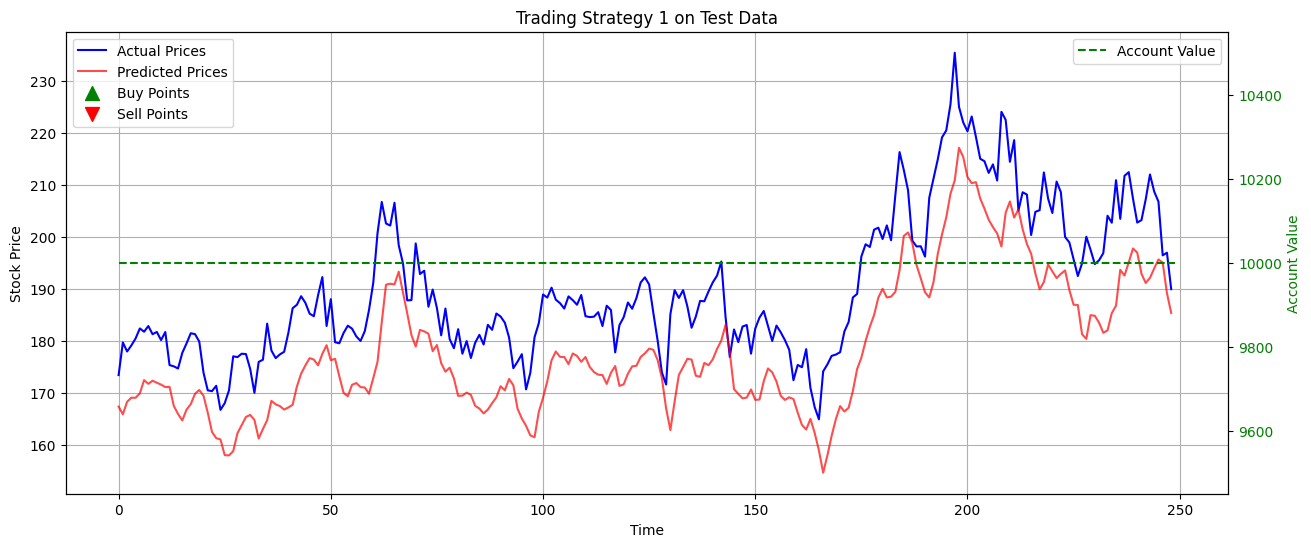

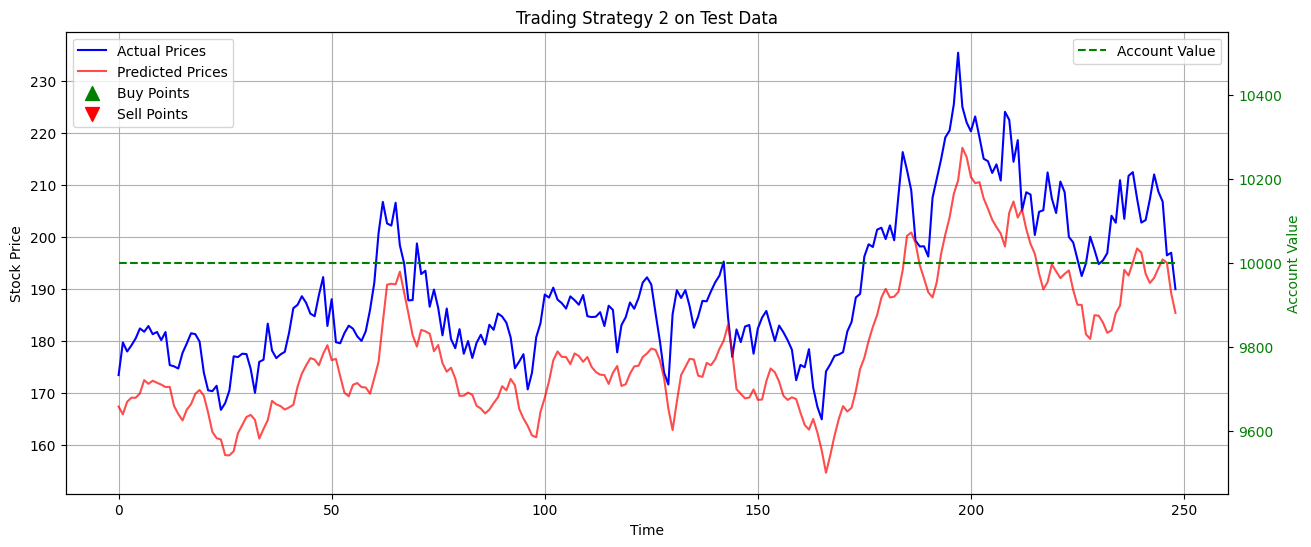

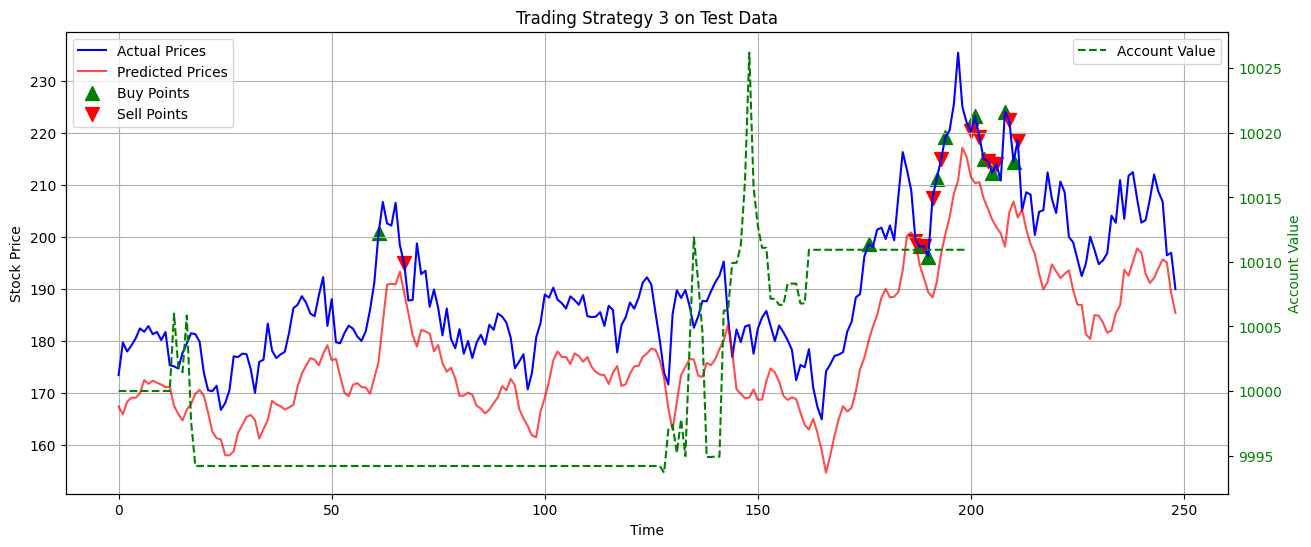

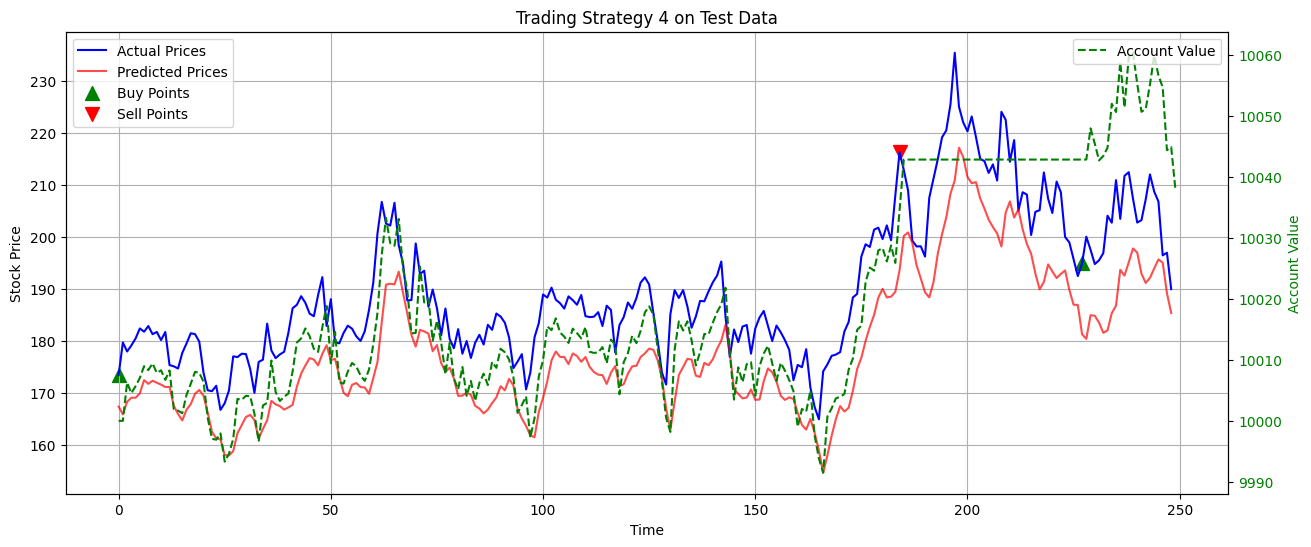

In [19]:
strategies = [
    (1, y_test_original, test_predictions_original, buy_points1, sell_points1, account_values1),
    (2, y_test_original, test_predictions_original, buy_points2, sell_points2, account_values2),
    (3, y_test_original, test_predictions_original, buy_points3, sell_points3, account_values3),
    (4, y_test_original, test_predictions_original, buy_points4, sell_points4, account_values4)
]

for strategy in strategies:
    plot_trading_strategy(*strategy)